# Mini-DLSS Initial Training Notebook

This notebook trains a small temporal super-resolution model for the project described in `dl project specs.md`.

Inputs per sample:
- `LR_t`: current 540p frame patch, cropped to `64x64`
- `HR_{t-1}`: previous 1080p frame patch, cropped to matching `128x128`
- `HR_t`: current 1080p target patch, cropped to matching `128x128`

The model upsamples `LR_t` to `128x128`, concatenates it with `HR_{t-1}`, predicts a residual image, and adds that residual to the upsampled LR image.

In [1]:
from pathlib import Path
from dataclasses import dataclass
import math
import random
import time

import cv2
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset
import matplotlib.pyplot as plt

torch.backends.cudnn.benchmark = True
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [2]:
@dataclass
class Config:
    hr_dir: Path = Path("dataset/HR")
    lr_dir: Path = Path("dataset/LR")
    checkpoint_dir: Path = Path("checkpoints")
    lr_patch_size: int = 64
    scale: int = 2
    batch_size: int = 8
    num_workers: int = 0  # Windows/Jupyter is usually most stable with 0 first.
    epochs: int = 1
    learning_rate: float = 2e-4
    val_fraction: float = 0.08
    seed: int = 42
    features: int = 48
    residual_blocks: int = 6
    use_amp: bool = True
    use_perceptual_loss: bool = False  # Enable later if torchvision VGG weights are available.
    perceptual_weight: float = 0.02
    max_train_batches: int | None = 20  # Use None for full training after the smoke test works.

cfg = Config()
cfg.checkpoint_dir.mkdir(exist_ok=True)

random.seed(cfg.seed)
np.random.seed(cfg.seed)
torch.manual_seed(cfg.seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(cfg.seed)

cfg

Config(hr_dir=WindowsPath('dataset/HR'), lr_dir=WindowsPath('dataset/LR'), checkpoint_dir=WindowsPath('checkpoints'), lr_patch_size=64, scale=2, batch_size=8, num_workers=0, epochs=1, learning_rate=0.0002, val_fraction=0.08, seed=42, features=48, residual_blocks=6, use_amp=True, use_perceptual_loss=False, perceptual_weight=0.02, max_train_batches=20)

## Dataset

This notebook uses a robust version of the dataset that keeps only frame names present in both `dataset/HR` and `dataset/LR`. Your current folders have a small count mismatch, so this prevents missing-target errors during training.

In [3]:
class TemporalPatchDataset(Dataset):
    def __init__(self, hr_dir, lr_dir, lr_patch_size=64, scale=2):
        self.hr_dir = Path(hr_dir)
        self.lr_dir = Path(lr_dir)
        self.lr_patch_size = lr_patch_size
        self.scale = scale
        self.hr_patch_size = lr_patch_size * scale

        hr_names = {p.name for p in self.hr_dir.glob("*.png")}
        lr_names = {p.name for p in self.lr_dir.glob("*.png")}
        self.frames = sorted(hr_names & lr_names)
        if len(self.frames) < 2:
            raise RuntimeError("Need at least two aligned HR/LR frames for temporal training.")

        missing_hr = len(lr_names - hr_names)
        missing_lr = len(hr_names - lr_names)
        print(f"Aligned frame pairs: {len(self.frames)}")
        print(f"LR files without HR target: {missing_hr}")
        print(f"HR files without LR input: {missing_lr}")

    def __len__(self):
        return len(self.frames) - 1

    def _read_rgb(self, path):
        image = cv2.imread(str(path), cv2.IMREAD_COLOR)
        if image is None:
            raise FileNotFoundError(path)
        return cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    def __getitem__(self, idx):
        prev_name = self.frames[idx]
        current_name = self.frames[idx + 1]

        lr_t = self._read_rgb(self.lr_dir / current_name)
        hr_prev = self._read_rgb(self.hr_dir / prev_name)
        hr_t = self._read_rgb(self.hr_dir / current_name)

        h, w, _ = lr_t.shape
        if h < self.lr_patch_size or w < self.lr_patch_size:
            raise ValueError(f"LR frame is smaller than patch size: {lr_t.shape}")

        x = random.randint(0, w - self.lr_patch_size)
        y = random.randint(0, h - self.lr_patch_size)
        hx, hy = x * self.scale, y * self.scale

        lr_crop = lr_t[y:y + self.lr_patch_size, x:x + self.lr_patch_size]
        hr_prev_crop = hr_prev[hy:hy + self.hr_patch_size, hx:hx + self.hr_patch_size]
        hr_crop = hr_t[hy:hy + self.hr_patch_size, hx:hx + self.hr_patch_size]

        lr_tensor = torch.from_numpy(lr_crop.copy()).permute(2, 0, 1).float() / 255.0
        hr_prev_tensor = torch.from_numpy(hr_prev_crop.copy()).permute(2, 0, 1).float() / 255.0
        hr_tensor = torch.from_numpy(hr_crop.copy()).permute(2, 0, 1).float() / 255.0
        return lr_tensor, hr_prev_tensor, hr_tensor


dataset = TemporalPatchDataset(cfg.hr_dir, cfg.lr_dir, cfg.lr_patch_size, cfg.scale)
val_size = max(1, int(len(dataset) * cfg.val_fraction))
train_size = len(dataset) - val_size
train_ds = Subset(dataset, range(0, train_size))
val_ds = Subset(dataset, range(train_size, len(dataset)))
print(f"Train samples: {len(train_ds)} | Validation samples: {len(val_ds)}")

Aligned frame pairs: 6294


LR files without HR target: 5
HR files without LR input: 1
Train samples: 5790 | Validation samples: 503


In [4]:
train_loader = DataLoader(
    train_ds,
    batch_size=cfg.batch_size,
    shuffle=True,
    num_workers=cfg.num_workers,
    pin_memory=torch.cuda.is_available(),
)
val_loader = DataLoader(
    val_ds,
    batch_size=cfg.batch_size,
    shuffle=False,
    num_workers=cfg.num_workers,
    pin_memory=torch.cuda.is_available(),
)

lr_t, hr_prev, hr_t = next(iter(train_loader))
print("LR_t:", tuple(lr_t.shape), "HR_prev:", tuple(hr_prev.shape), "HR_t:", tuple(hr_t.shape))

LR_t: (8, 3, 64, 64) HR_prev: (8, 3, 128, 128) HR_t: (8, 3, 128, 128)


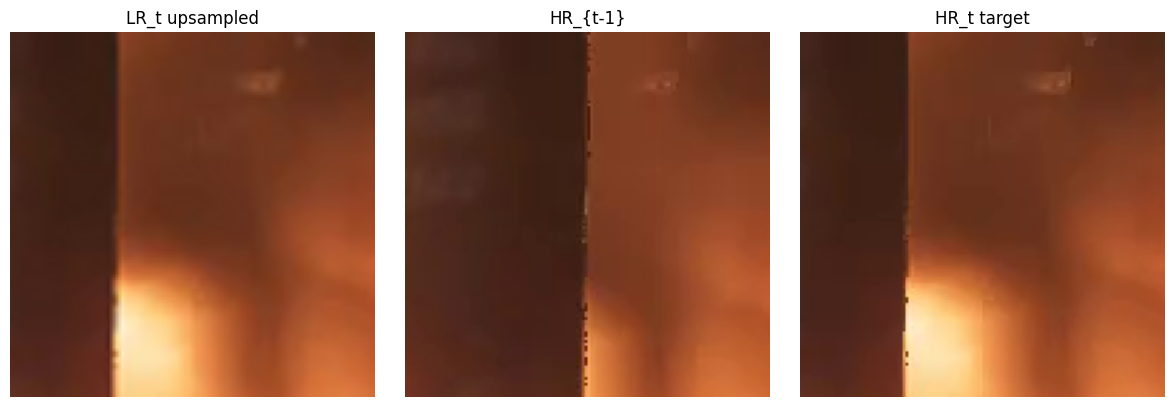

In [5]:
def show_triplet(lr_t, hr_prev, hr_t, index=0):
    lr_up = F.interpolate(lr_t[index:index + 1], scale_factor=cfg.scale, mode="bicubic", align_corners=False)[0]
    images = [lr_up, hr_prev[index], hr_t[index]]
    titles = ["LR_t upsampled", "HR_{t-1}", "HR_t target"]
    plt.figure(figsize=(12, 4))
    for i, (image, title) in enumerate(zip(images, titles), start=1):
        plt.subplot(1, 3, i)
        plt.imshow(image.permute(1, 2, 0).clamp(0, 1))
        plt.title(title)
        plt.axis("off")
    plt.tight_layout()

show_triplet(lr_t, hr_prev, hr_t)

## Model

The LR patch must be upscaled before temporal concatenation because `LR_t` is `64x64` and `HR_{t-1}` is `128x128`. The network receives a `6x128x128` tensor and predicts a residual correction over bicubic upsampling.

In [6]:
class ResidualBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(channels, channels, kernel_size=3, padding=1),
            nn.LeakyReLU(0.1, inplace=True),
            nn.Conv2d(channels, channels, kernel_size=3, padding=1),
        )

    def forward(self, x):
        return x + self.net(x) * 0.1


class TemporalSRNet(nn.Module):
    def __init__(self, features=48, residual_blocks=6, scale=2):
        super().__init__()
        self.scale = scale
        self.head = nn.Sequential(
            nn.Conv2d(6, features, kernel_size=3, padding=1),
            nn.LeakyReLU(0.1, inplace=True),
        )
        self.body = nn.Sequential(*[ResidualBlock(features) for _ in range(residual_blocks)])
        self.tail = nn.Conv2d(features, 3, kernel_size=3, padding=1)

    def forward(self, lr_t, hr_prev):
        lr_up = F.interpolate(lr_t, scale_factor=self.scale, mode="bicubic", align_corners=False)
        x = torch.cat([lr_up, hr_prev], dim=1)
        residual = self.tail(self.body(self.head(x)))
        return (lr_up + residual).clamp(0.0, 1.0)


model = TemporalSRNet(cfg.features, cfg.residual_blocks, cfg.scale).to(device)
params = sum(p.numel() for p in model.parameters())
print(f"Model parameters: {params:,}")

with torch.no_grad():
    test_out = model(lr_t[:1].to(device), hr_prev[:1].to(device))
print("Output shape:", tuple(test_out.shape))

Model parameters: 253,347


Output shape: (1, 3, 128, 128)


## Losses

The default loss is Charbonnier loss, a smooth L1-style image loss that is usually less blurry than pure MSE. Optional VGG perceptual loss is included but disabled by default because it may need pretrained weights from `torchvision`.

In [7]:
class CharbonnierLoss(nn.Module):
    def __init__(self, eps=1e-3):
        super().__init__()
        self.eps = eps

    def forward(self, pred, target):
        return torch.sqrt((pred - target) ** 2 + self.eps ** 2).mean()


class VGGPerceptualLoss(nn.Module):
    def __init__(self):
        super().__init__()
        from torchvision.models import vgg16, VGG16_Weights
        weights = VGG16_Weights.DEFAULT
        vgg = vgg16(weights=weights).features[:16].eval()
        for param in vgg.parameters():
            param.requires_grad = False
        self.vgg = vgg
        self.register_buffer("mean", torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1))
        self.register_buffer("std", torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1))

    def forward(self, pred, target):
        pred = (pred - self.mean) / self.std
        target = (target - self.mean) / self.std
        return F.l1_loss(self.vgg(pred), self.vgg(target))


pixel_loss = CharbonnierLoss().to(device)
perceptual_loss = None
if cfg.use_perceptual_loss:
    perceptual_loss = VGGPerceptualLoss().to(device)

def compute_loss(pred, target):
    loss = pixel_loss(pred, target)
    if perceptual_loss is not None:
        loss = loss + cfg.perceptual_weight * perceptual_loss(pred, target)
    return loss

In [8]:
def psnr(pred, target, eps=1e-8):
    mse = F.mse_loss(pred, target).item()
    return 10.0 * math.log10(1.0 / max(mse, eps))


@torch.no_grad()
def evaluate(model, loader, max_batches=20):
    model.eval()
    losses = []
    psnrs = []
    for batch_idx, (lr_t, hr_prev, hr_t) in enumerate(loader):
        lr_t = lr_t.to(device, non_blocking=True)
        hr_prev = hr_prev.to(device, non_blocking=True)
        hr_t = hr_t.to(device, non_blocking=True)
        pred = model(lr_t, hr_prev)
        losses.append(compute_loss(pred, hr_t).item())
        psnrs.append(psnr(pred, hr_t))
        if batch_idx + 1 >= max_batches:
            break
    return float(np.mean(losses)), float(np.mean(psnrs))

## Training

In [9]:
optimizer = torch.optim.AdamW(model.parameters(), lr=cfg.learning_rate, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=cfg.epochs)
amp_enabled = cfg.use_amp and device.type == "cuda"
scaler = torch.amp.GradScaler("cuda", enabled=amp_enabled)

best_val = float("inf")
history = []

for epoch in range(1, cfg.epochs + 1):
    model.train()
    start = time.time()
    running = []

    for batch_idx, (lr_t, hr_prev, hr_t) in enumerate(train_loader, start=1):
        lr_t = lr_t.to(device, non_blocking=True)
        hr_prev = hr_prev.to(device, non_blocking=True)
        hr_t = hr_t.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        with torch.amp.autocast(device_type=device.type, enabled=amp_enabled):
            pred = model(lr_t, hr_prev)
            loss = compute_loss(pred, hr_t)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()

        running.append(loss.item())
        if batch_idx % 50 == 0:
            print(f"Epoch {epoch} batch {batch_idx}/{len(train_loader)} | loss {np.mean(running[-50:]):.5f}")
        if cfg.max_train_batches is not None and batch_idx >= cfg.max_train_batches:
            break

    scheduler.step()
    train_loss = float(np.mean(running))
    val_loss, val_psnr = evaluate(model, val_loader)
    elapsed = time.time() - start
    history.append({"epoch": epoch, "train_loss": train_loss, "val_loss": val_loss, "val_psnr": val_psnr})
    print(f"Epoch {epoch}: train {train_loss:.5f} | val {val_loss:.5f} | PSNR {val_psnr:.2f} dB | {elapsed:.1f}s")

    checkpoint = {
        "epoch": epoch,
        "model_state": model.state_dict(),
        "optimizer_state": optimizer.state_dict(),
        "config": cfg.__dict__,
        "history": history,
    }
    torch.save(checkpoint, cfg.checkpoint_dir / "last.pt")
    if val_loss < best_val:
        best_val = val_loss
        torch.save(checkpoint, cfg.checkpoint_dir / "best.pt")
        print("Saved new best checkpoint.")

Epoch 1: train 0.03056 | val 0.02048 | PSNR 28.64 dB | 27.4s
Saved new best checkpoint.


## Preview

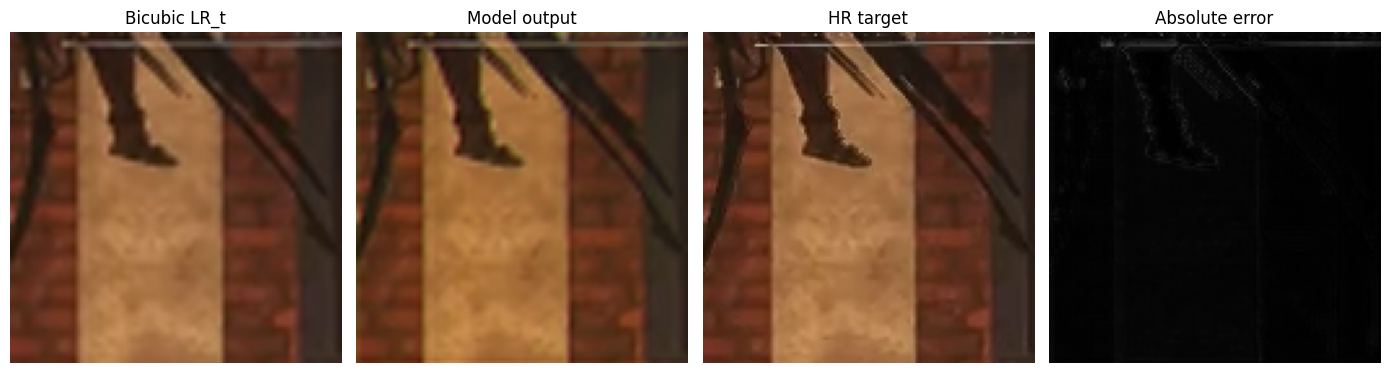

In [10]:
@torch.no_grad()
def preview_prediction(model, loader):
    model.eval()
    lr_t, hr_prev, hr_t = next(iter(loader))
    lr_t = lr_t.to(device)
    hr_prev = hr_prev.to(device)
    pred = model(lr_t, hr_prev).cpu()[0]
    lr_up = F.interpolate(lr_t[:1].cpu(), scale_factor=cfg.scale, mode="bicubic", align_corners=False)[0]
    target = hr_t[0]

    images = [lr_up, pred, target, (pred - target).abs().mean(0, keepdim=True).repeat(3, 1, 1)]
    titles = ["Bicubic LR_t", "Model output", "HR target", "Absolute error"]
    plt.figure(figsize=(14, 4))
    for i, (image, title) in enumerate(zip(images, titles), start=1):
        plt.subplot(1, 4, i)
        plt.imshow(image.permute(1, 2, 0).clamp(0, 1))
        plt.title(title)
        plt.axis("off")
    plt.tight_layout()

preview_prediction(model, val_loader)

## Next Steps

- Run one smoke test first: set `max_train_batches=20` and `epochs=1`.
- If memory is stable, use the full loader with `batch_size=8`; reduce to `4` if CUDA runs out of memory.
- After the baseline learns, enable perceptual loss or add a temporal consistency loss between consecutive predictions.